abs_rho_error                     relative_error            \
                      mean    median       max           mean    median   
lattice_type                                                              
cubic             0.014313  0.012493  0.047285       0.026486  0.024614   
fcc               0.010841  0.009470  0.042072       0.019925  0.018772   

                        
                   max  
lattice_type            
cubic         0.079067  
fcc           0.066880

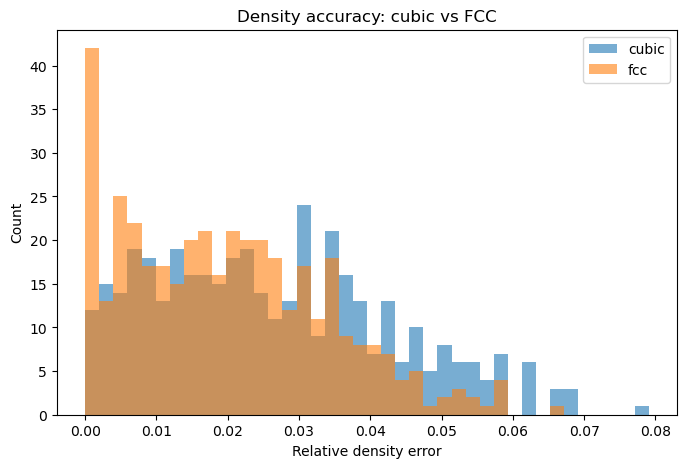

In [2]:
import numpy as np
import pandas as pd
from md_Helpers import Create_Lattices as cl
import matplotlib.pyplot as plt

BoxLengths = np.arange(50, 100, 2)
rhos = np.arange(0.2, 1.0, 0.05)

rows = []

for lattice_type in ["cubic", "fcc"]:
    for L in BoxLengths:
        for rho in rhos:
            if lattice_type == "cubic":
                pos = cl.FillBoxCubicLattice(L, rho)
            elif lattice_type == "fcc":
                pos = cl.FillBoxFccLattice(L, rho)

            actual_rho = len(pos) / L**3

            rows.append({
                "lattice_type": lattice_type,
                "BoxLength": L,
                "rho_target": rho,
                "N": len(pos),
                "rho_actual": actual_rho,
                "rho_error": actual_rho - rho,
                "abs_rho_error": abs(actual_rho - rho),
                "relative_error": abs(actual_rho - rho) / rho,
            })

df = pd.DataFrame(rows)

summary = (
    df.groupby("lattice_type")
      [["abs_rho_error", "relative_error"]]
      .agg(["mean", "median", "max"])
)

display(summary)





all_errors = df["relative_error"]

bins = np.linspace(
    all_errors.min(),
    all_errors.max(),
    41,   # 40 bins
)

plt.figure(figsize=(8, 5))

for lattice_type in ["cubic", "fcc"]:
    sub = df[df["lattice_type"] == lattice_type]

    plt.hist(
        sub["relative_error"],
        bins=bins,
        alpha=0.6,
        label=lattice_type,
    )

plt.xlabel("Relative density error")
plt.ylabel("Count")
plt.legend()
plt.title("Density accuracy: cubic vs FCC")
plt.show()

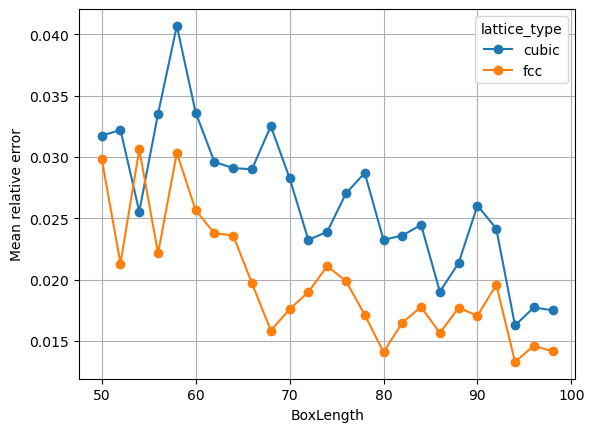

In [3]:
mean_error_vs_L = (
    df.groupby(["lattice_type", "BoxLength"])
      ["relative_error"]
      .mean()
      .unstack()
      .T
)

mean_error_vs_L.plot(marker="o")
plt.ylabel("Mean relative error")
plt.grid()
plt.show()

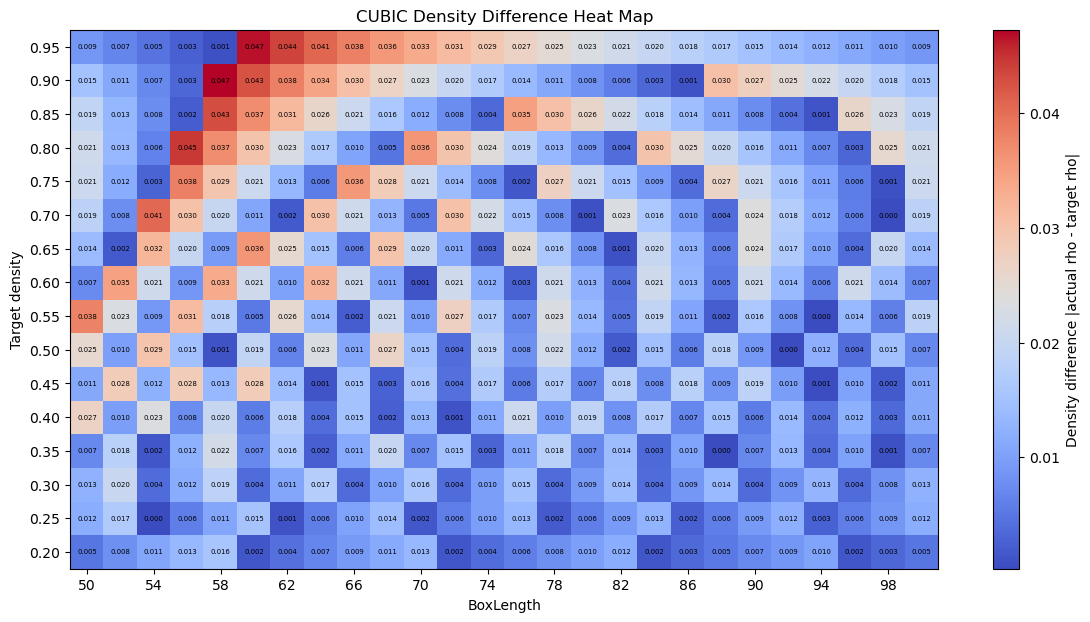

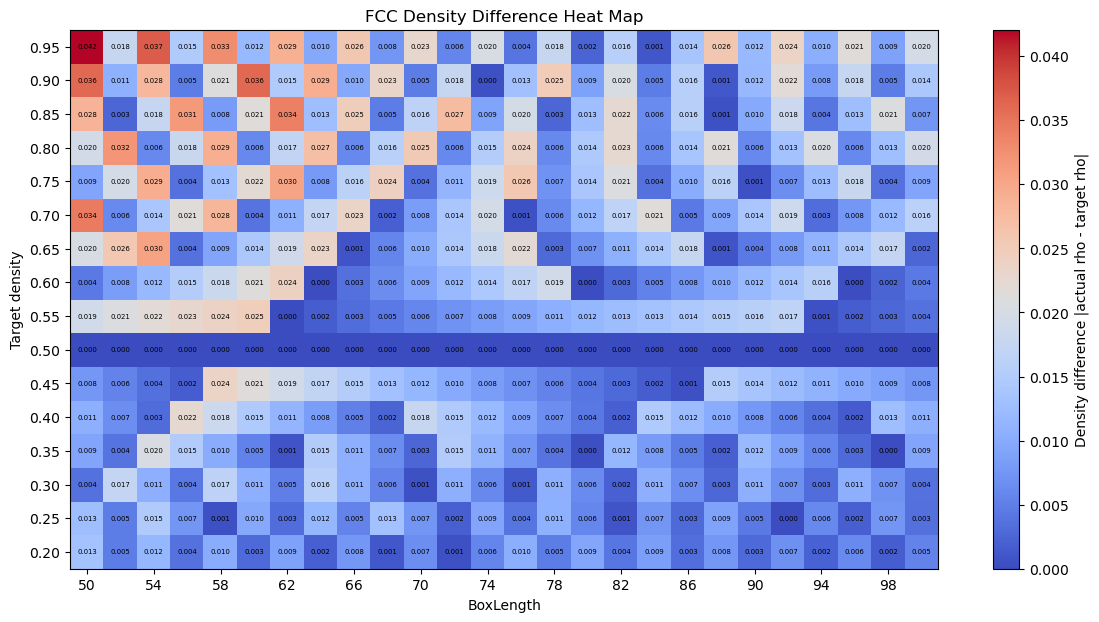

In [5]:
# ============================================================
# Density difference heatmaps: Cubic vs FCC
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parameter grid
# ============================================================

box_lengths = np.arange(50, 101, 2)
target_rhos = np.arange(0.2, 1.0, 0.05)

# ============================================================
# Helper function
# ============================================================

def compute_density_difference_grid(lattice_type, box_lengths, target_rhos):
    density_diff = np.zeros((len(target_rhos), len(box_lengths)))

    for i, rho in enumerate(target_rhos):
        for j, BoxLength in enumerate(box_lengths):

            if lattice_type == "cubic":
                positions = cl.FillBoxCubicLattice(BoxLength, rho)

            elif lattice_type == "fcc":
                positions = cl.FillBoxFccLattice(BoxLength, rho)

            else:
                raise ValueError("lattice_type must be 'cubic' or 'fcc'")

            actual_rho = len(positions) / BoxLength**3
            density_diff[i, j] = abs(actual_rho - rho)

    return density_diff


def plot_density_heatmap(density_diff, lattice_type, box_lengths, target_rhos):
    plt.figure(figsize=(14, 7))

    im = plt.imshow(
        density_diff,
        origin="lower",
        aspect="auto",
        extent=[
            box_lengths[0] - 1,
            box_lengths[-1] + 1,
            target_rhos[0] - 0.025,
            target_rhos[-1] + 0.025,
        ],
        cmap="coolwarm",
    )

    plt.colorbar(im, label="Density difference |actual rho - target rho|")
    plt.xlabel("BoxLength")
    plt.ylabel("Target density")
    plt.title(f"{lattice_type.upper()} Density Difference Heat Map")

    plt.xticks(box_lengths[::2])
    plt.yticks(target_rhos)

    # annotate values
    for i, rho in enumerate(target_rhos):
        for j, BoxLength in enumerate(box_lengths):
            plt.text(
                BoxLength,
                rho,
                f"{density_diff[i, j]:.3f}",
                ha="center",
                va="center",
                fontsize=5,
            )

    plt.show()


# ============================================================
# Compute grids
# ============================================================

cubic_density_diff = compute_density_difference_grid(
    lattice_type="cubic",
    box_lengths=box_lengths,
    target_rhos=target_rhos,
)

fcc_density_diff = compute_density_difference_grid(
    lattice_type="fcc",
    box_lengths=box_lengths,
    target_rhos=target_rhos,
)

# ============================================================
# Plot heatmaps
# ============================================================

plot_density_heatmap(
    cubic_density_diff,
    lattice_type="cubic",
    box_lengths=box_lengths,
    target_rhos=target_rhos,
)

plot_density_heatmap(
    fcc_density_diff,
    lattice_type="fcc",
    box_lengths=box_lengths,
    target_rhos=target_rhos,
)